# 3.60 Pointed -- NIR Wavelength Calibration

OVERVIEW: The goal of this activity is to acquire and analyze data sufficient for wavelength calibration of the Pandora NIR prism spectra. This is related to but separate from measuring the wavelength limits and the absolute photometric performance of the Pandora NIR channel. NIR wavelength calibration will be determined by taking the spectra of a post-AGB star.


MORE DETAILS: We will use the line list provided in Table 1 of Kuntschner et al. (2010, Proc SPIE 7731); this was used for wavelength calibration observations of HST WFC3 G141 grism data(https://www.stsci.edu/hst/phase2-public/16407.pro) using the protoplanetary nebula Vy2-2 (http://simbad.cds.unistra.fr/simbad/sim-id?Ident=%402707077&Name=PN%20Vy%20%202-2&submit=submit; V=13.8; J = 10.8 mag; Clegg et al. 1989, IAUS, 131, 433C; https://ui.adsabs.harvard.edu/abs/1989IAUS..131..443C/abstract) and IC 5117 (http://simbad.cfa.harvard.edu/simbad/sim-id Ident=IC+5117&submit=submit+id; V = 16.7, J=11.3 mag; Rudy et al. 2001; https://ui.adsabs.harvard.edu/abs/2001AJ....121..362R/abstract). Note that HST had better luck with IC 5117 per Pirzkal et al. (2016) (https://ui.adsabs.harvard.edu/abs/2016wfc..rept...15P/abstract). The object should be positioned at the fiducial target field point within the science subarray as determined by the VIS field location.


DATA PRODUCTS: 
    This data will be utilized to generate a polynomial that provides the mapping between the wavelength and detector positions for several object locations within the NIR science subarray field.


EXIT CRITERIA: observation obtained, analysis complete and summarized in 3.60_ResultsSummary.md
- AGB/PNe observations were obtained with TBD S/N at the nominal boresight in the NIR science subarray and uncontaminated by any adjacent spectra
- AGB/PNe observations were obtained with TBD S/N at any secondary locations within NIR subarray boresight and uncontaminated by any adjacent spectra
- Does the resulting wavelength solution have sufficient accuracy to meet Pandora's requirements?


DATA VOLUME: 5 observations, simultaneous VIS and NIR, 9 50x50 VIS regions, 1 84x400 NIR region. Each observation has the same set up, pointed at a different target. 


TARGET CRITERIA: Well studied AGB/PNe with well known spectra. Ideally farther away from the Earth, Moon, and other bright sources than the nominal keep out ranges.
- candidate targets: protoplanetary nebula Vy2-2; IC 5117


KEY STAKEHOLDERS: Tom Greene


## Load in 

In [1]:
''' Make sure you have pandorasim installed and updated '''
import pandorasat as ps
import pandorasim as pp
ps.phoenix.get_phoenix_model(teff=7000, jmag=10) 
from pandorasim import VisibleSim, NIRSim
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord, Distance, Longitude
from astropy.io import fits
from pandorasat.plotting import animate
from pandorasat.plotting import save_mp4, save_gif
from astropy.time import Time, TimeDelta
import matplotlib.patches as patches

### Importing additional functions and constants used in this notebook
import sys, os
sys.path.append(os.path.abspath('..'))
from CommissFunctions import generate_task_plan 
from CommissFunctions import data_rate, bits_per_pix_VIS, compression_fractor_VIS, frame_time_VIS, stored_frames_per_int_VIS, pass_time_min, regions_NIR, bits_per_pix_NIR, compression_fractor_NIR, NIR_ra_shape, NIR_dec_shape, VIS_ra_shape, VIS_dec_shape


In [2]:
ps.__version__

'0.12.6'

## Data Volume

5 observations for 5 different standard stars. Simultaneous VIS and NIR. The observing set up is the same for all 5 observations.

In [3]:
num_observations = 5

In [4]:
##### VIS Observations #####
frames_per_int_VIS      = 50
regions_VIS             = 9
VIS_xpix                = 50
VIS_ypix                = 50
num_int_VIS             = 2400
bits_per_int_VIS        = VIS_xpix * VIS_ypix * regions_VIS * bits_per_pix_VIS * stored_frames_per_int_VIS
int_and_reset_time_VIS  = frame_time_VIS * frames_per_int_VIS
bits_per_sec_VIS        = bits_per_int_VIS / int_and_reset_time_VIS
bits_per_sec_comp_VIS   = bits_per_sec_VIS / compression_fractor_VIS
test_time_VIS           = num_int_VIS * int_and_reset_time_VIS
bits_test_total_VIS     = bits_per_sec_comp_VIS * test_time_VIS
Gbits_test_packet_VIS   = bits_test_total_VIS / 1E9 * 1.1 * 1.25
downlinks_VIS           = Gbits_test_packet_VIS * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observations:', Gbits_test_packet_VIS*num_observations, 'Gbits')


VIS Observations: 4.752000000000001 Gbits


In [5]:
##### NIR Observations #####
NIR_xpix                   = 80
NIR_ypix                   = 400
NIR_ROI_StartX             = 1968
NIR_ROI_StartY             = 824
NIR_ROI_SizeX              = 80
NIR_ROI_SizeY              = 400
frames_per_int_NIR         = 19
stored_frames_per_int_NIR  = 2
num_int_NIR                = 3417
frame_time_NIR             = (NIR_xpix+12) * (NIR_ypix+2) * 0.00001 #sec
int_and_reset_time_NIR     = frame_time_NIR * (frames_per_int_NIR+1)
bits_per_int_NIR           = NIR_xpix * NIR_ypix * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR
bits_per_sec_NIR           = bits_per_int_NIR / int_and_reset_time_NIR
test_time_NIR              = num_int_NIR * int_and_reset_time_NIR
bits_per_sec_comp_NIR      = bits_per_sec_NIR / compression_fractor_NIR
bits_test_total_NIR        = bits_per_sec_comp_NIR * test_time_NIR
Gbits_test_packet_NIR      = bits_test_total_NIR / 1E9 * 1.1 * 1.25
downlinks_NIR              = Gbits_test_packet_NIR * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observations:', Gbits_test_packet_NIR*num_observations, 'Gbits')
observing_time = 6.67*3600 #sec
NIR_SC_Integrations = observing_time / (frames_per_int_NIR * frame_time_NIR) #dimensionless
round(NIR_SC_Integrations)

NIR Observations: 14.433408 Gbits


3417

### Total Data Volume

In [6]:
Gbits_total = (Gbits_test_packet_VIS + Gbits_test_packet_NIR) * num_observations
downlinks_total = (downlinks_VIS + downlinks_NIR) * num_observations
test_time_total = np.max([test_time_VIS, test_time_NIR]) * num_observations

print('Test time, total, no slew/overhead time:', test_time_total/60/60, 'hours')
print('Volume, total:', Gbits_total, 'Gbits')
print('Downlinks, total:', downlinks_total)

Test time, total, no slew/overhead time: 35.10398 hours
Volume, total: 19.185408000000002 Gbits
Downlinks, total: 7.993920000000001


## Define 5 Targets

In [6]:
### Possible Targets:
# ...
# ...
# ...
# ...
# ...
# ...
# ...
# ...

In [7]:
Targets = ["HD_79349", "HD_70138", "BD-16_1934", "U_Crt", "IRAS_09484-6242"]

## The rest of this notebook should be run for each of the 5 targets. Select an observation number

In [8]:
observation_number = 4
target = Targets[observation_number]

In [9]:
''' Finds target coordinates based on astropy '''
### You can do this differently as long as you have DEC and RA
c = SkyCoord.from_name(target)


''' Identify the start time and end time of the observation '''
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
test_time = max(test_time_VIS, test_time_NIR)
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta


''' Initialize a simulator object '''
simVIS = VisibleSim(ROI_size=(VIS_xpix, VIS_ypix), nROIs=regions_VIS) 
simNIR = NIRSim() 

''' Point the simulator to the corrected location '''
###        RA,   DEC,    Theta 
theta0     = 0*u.deg
simVIS.point(c.ra, c.dec, theta0)
simNIR.point(c.ra, c.dec, theta0)

KeyboardInterrupt: 

## Generate Simulated Observation

### VIS Observation

In [ ]:
''' Plot the VIS Full Frame Image. ROIs are in red boxes defining the subarrays. '''
simVIS.show_FFI()

In [11]:
''' Create an Observation. '''
### This returns an astropy.io.fits.HDUList array. 
# `nreads` sets how many reads of the detector are coadded together to create a frame.
# `bin_frames` is a shortcut parameter to speed up computation. Must be a factor of nreads. We can ignore this for low nreads. 
# `nframes` sets how many frames will be returned.
# `start_time` indicates the time of observation. 
# `output_type` is set to array, for now. This make it easy to call, but we'll save it as a fits file later. 
###

### reduce the number of integrations to speed up calculations
reduction = 100 # set to 1 for no reduction
data = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(num_int_VIS/reduction), start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

python(12502) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Modeling Pixel Positions: 100%|███████████████████████████████████████| 18/18 [00:01<00:00, 12.35it/s]


(9, 24, 50, 50)

### NIR Observation

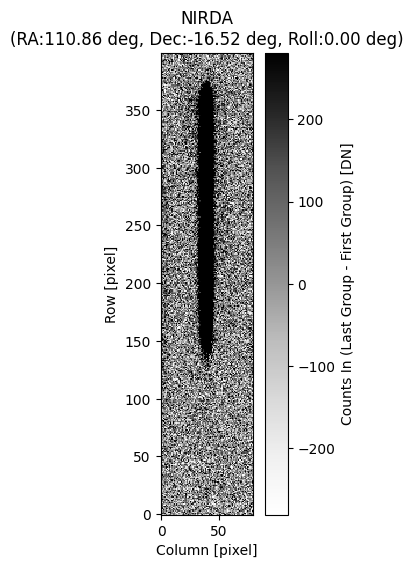

In [12]:
''' Plot the NIRDA subarray '''
simNIR.show_subarray();

In [13]:
''' Create a NIRDA observation. '''
### This returns an astropy.io.fits.HDUList array. The following parameters can be adjusted
# SC_Resets1 : Number of reset frames at the start of the first integration of exposure
# SC_Resets2 : Number of resent frames at the start of 1 through n integrations of exposure
# SC_DropFrames1 : Number of dropped frames after reset of any integration of exposure
# SC_DropFrames2 : Number of dropped frames in every group of integrations of exposure except the last group
# SC_DropFrames3 : Number of dropped frames in the last group of each integration of exposure
# SC_ReadFrames : Number of frames read during each group of integration of exposure
# SC_Groups : Number of groups per integration of exposure
# SC_Integrations : Number of integrations per exposure
# start_time : Time to start the observation. This is only used if returning a fits file, or supplying a flux function.
# noise : bool flag determining whether noise is simulated and included. Default is True.
# jitter : bool flag determining whether jitter is simulated and included. Default is True.
# output_type : String flag to determine the result output. Valid strings are "fits" or "array
###

data = simNIR.observe(SC_Integrations=int(num_int_NIR/reduction), SC_ReadFrames=stored_frames_per_int_NIR, start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions:   0%|                                                | 0/10 [00:16<?, ?it/s]


KeyboardInterrupt: 

## Save the Simulated Observation

In [14]:
''' Re-Create the observations in the correct format for the .fits file (i.e., output_type set to default) '''
### Before, object_type was array for easy computation in this notebook, but that is not correct for the .fits file
hdulist_vis = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(num_int_VIS/reduction), start_time=start_time)
hdulist_nir = simNIR.observe(SC_Integrations=int(num_int_NIR/reduction), SC_ReadFrames=stored_frames_per_int_NIR, start_time=start_time)


''' Save our simulated observation in a fits file '''
targ = target.replace(" ", "")
VISrois_outfile = "3.60_VISrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
NIRrois_outfile = "3.60_NIRrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
hdulist_vis.writeto(VISrois_outfile, overwrite=True)
hdulist_nir.writeto(NIRrois_outfile, overwrite=True)

Modeling Pixel Positions:  44%|█████████████████▊                      | 4/9 [09:32<11:55, 143.05s/it]


KeyboardInterrupt: 

In [15]:
### Show what is in our fits file: 
'''
Three FITS file extensions: 
    (1) PRIMARY: information about the simulated observation 
    (2) SCIENCE: data info, images
    (3) ROITABLE: VISDA pixel coordinates of the origin of the subarray, which is defined as the lower left corner
'''

hdul_rois = fits.open(VISrois_outfile) ### or NIRrois_outfile
print(hdul_rois.info())

#print('.')
#print('.')
#print('.')
#print('-- PRIMARY Headers --')
#print(hdul_rois[0].header)

#print('.')
#print('.')
#print('.')
#print('-- SCIENCE Headers --')
#print(hdul_rois[1].header)

#print('.')
#print('.')
#print('.')
#print('-- ROITABLE Headers --')
#print(hdul_rois[2].header)

NameError: name 'VISrois_outfile' is not defined

## Data Products

### Generate a polynomial that provides the mapping between the wavelength and detector positions for several object locations within the NIR science subarray field.

## Generate SOC File

In [10]:
Targets

['HD_79349', 'HD_70138', 'BD-16_1934', 'U_Crt', 'IRAS_09484-6242']

In [28]:
### Select which target to observe (include if skipping the simulation step above)
obs = 4
target = Targets[obs]

### Finds target coordinates based on astropy
### You can do this differently as long as you have DEC and RA
c = SkyCoord.from_name(target)
ras = [137.9291169934, 124.92954131978509, 110.86363259834353, 168.18873385862784, 147.32946223997396]
decs = [-48.7731097334, -18.264668306227144, -16.522086797910916, -7.298499132847719, -63.011288968151106]
pmra = [-30.39339396994682, -2.8378254319496246, -8.629914548209712, -6.658462067305343, -5.4291259701415004]
pmdec = [16.783768254599217, 3.246795490838088, 8.656588381836494, -2.2364405308457544, 1.2451552709488283]
plx = [2.095200607308628, 0.42406468589865765, 0.7138827829094831, 1.7147308198691762, 1.563045347272378]
rv = [47.106068, 0, 98.122444, 0, 38.88855]
roi_ras = [
    [137.87866024476756, 137.81776507597255, 137.7664410762592, 138.064575506063, 137.63847551341476, 137.7657897254652, 138.2536749931146, 138.05734455050236],
    [124.9722129834121, 125.01470591489526, 124.85808753404952, 124.78450784174706, 124.96241886322397, 124.77108668382587, 125.0396563272338, 124.85410921361873],
    [110.84583479278649, 110.90506437267747, 110.9390649697273, 110.96341011320513, 111.02637408028188, 110.9574152331099, 110.91093223642095, 110.69954263112635],
    [168.20235065590379, 168.25672046387905, 168.14013705176347, 168.31582936925048, 168.25441863075184, 168.3697255938189, 168.02091541512553, 168.14914376386992],
    [147.26760818006747, 147.2650076197231, 147.2106277910077, 147.3773103152573, 147.14878862051535, 147.41778975538094, 147.84136133743075, 147.88943639784813]
]
roi_decs = [
    [-48.67176892737788, -48.68231893477585, -48.868753010480496, -48.61231983426351, -48.795277670045856, -48.9629187670047, -48.82282316350241, -49.02363159439342],
    [-18.35418388846603, -18.20788945445495, -18.178068764491666, -18.323255574207444, -18.11793135709613, -18.238942530654793, -18.379130472960725, -18.46514168307516],
    [-16.569064955227407, -16.607334316489613, -16.601627621240635, -16.598853914719662, -16.39745050520015, -16.34336106675983, -16.320118601089177, -16.37312835234432],
    [-7.328162739371529, -7.260278837795642, -7.375764325086901, -7.201833262737327, -7.4802097205683, -7.401390163806177, -7.1465645119087196, -7.523295711584283],
    [-63.02285220204024, -63.02225790342177, -62.99546185604061, -62.793185710287226, -62.85535378784422, -62.7672201679198, -63.05296522417219, -63.01659061786399]
]

### Identify the start time and end time of the observation
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
test_time = max(test_time_VIS, test_time_NIR)
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta

c = SkyCoord(
    ra=ras[obs]*u.deg,
    dec=decs[obs]*u.deg,
    pm_ra_cosdec=pmra[obs]*u.mas/u.year,
    pm_dec=pmdec[obs]*u.mas/u.year,
    obstime=Time.strptime("2016", "%Y"),
    distance=Distance(parallax=plx[obs] * u.mas, allow_negative=True),
    radial_velocity=rv[obs]*u.km/u.s
).apply_space_motion(start_time)

roi_ras[obs].insert(0, c.ra.value)
roi_decs[obs].insert(0, c.dec.value)

In [ ]:
'Here we define the information required for scheduling the observation.'''
### Some variables may be removed/added/changed. Working on defining these with SOC meetings. 
### This is not all correct! Revisit and check once notebook is complete. 

variables = {
    'visit_id': '0360', ### setting based on task number. Could change. 
    'obs_id': f"{obs:03}", ### setting based on observation number. 
    'target': target, 
    'priority': 1, ### all commissioning is priority 1
    'start_time': start_time.strftime('%Y-%m-%dT%H:%M:%SZ'), 
    'stop_time': end_time.strftime('%Y-%m-%dT%H:%M:%SZ'),
    'RA': c.ra.value,
    'DEC': c.dec.value, 
    'ffi_flag':0,
    
    'NIR_AvgGroups': 1, ### check what this is
    'NIR_ROI_StartX': NIR_ROI_StartX, 
    'NIR_ROI_StartY': NIR_ROI_StartY, 
    'NIR_ROI_SizeX': NIR_ROI_SizeX, 
    'NIR_ROI_SizeY': NIR_ROI_SizeY,
    'NIR_SC_Resets1': 1,
    'NIR_SC_Resets2': 1, 
    'NIR_SC_DropFrames1': 0,
    'NIR_SC_DropFrames2': 16,
    'NIR_SC_DropFrames3': 0, 
    'NIR_SC_ReadFrames': int(stored_frames_per_int_NIR/2),#frames_per_int_NIR,
    'NIR_targetID': target, 
    'NIR_SC_Groups': 2,
    'NIR_SC_Integrations': round(NIR_SC_Integrations),
    
    'VIS_StarRoiDetMethod': 1,  ### 1: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 2: Run star detection algorithm on first image and obtain star ROIs from results.
    'VIS_FramesPerCoadd': frames_per_int_VIS, 
    'VIS_NumTotalFramesRequested': frames_per_int_VIS * num_int_VIS, #GO OVER THIS
    'VIS_TargetRA': c.ra.value, 
    'VIS_TargetDEC': c.dec.value, 
    'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
    'VIS_StarRoiDimension': [VIS_xpix, VIS_ypix], 
    'VIS_MaxNumStarRois': 9, ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
    'VIS_numPredefinedStarRois': 9, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
    'VIS_PredefinedStarRoiRa': roi_ras[obs], ### currently defining as corner of ROI. We may update this to be ROI centers.
    'VIS_PredefinedStarRoiDec': roi_decs[obs], 
    'VIS_targetID': target, 
    'VIS_NumExposuresMax': 1, 
    'VIS_ExposureTime_us': int(frame_time_VIS * 1000000)
}

In [30]:
'''Generate the SOC .xml file'''

output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_SOC.xml' 
generate_task_plan(variables, output_soc_file)